# Retail Sales Exploratory Data Analysis (EDA)

#### Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading and Cleaning

In [36]:
df = pd.read_csv('superstore_dataset.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         1043 non-null   int64  
 1   Order ID       1043 non-null   str    
 2   Order Date     1043 non-null   str    
 3   Ship Date      1043 non-null   str    
 4   Ship Mode      1043 non-null   str    
 5   Customer ID    1043 non-null   str    
 6   Customer Name  1043 non-null   str    
 7   Segment        1043 non-null   str    
 8   Country        1043 non-null   str    
 9   City           1043 non-null   str    
 10  State          1043 non-null   str    
 11  Postal Code    1043 non-null   int64  
 12  Region         1043 non-null   str    
 13  Product ID     1043 non-null   str    
 14  Category       1043 non-null   str    
 15  Sub-Category   1043 non-null   str    
 16  Product Name   1043 non-null   str    
 17  Sales          1042 non-null   float64
 18  Quantity       1042

In [38]:
df.shape

(1043, 21)

In [39]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            1
Quantity         1
Discount         1
Profit           1
dtype: int64

In [40]:
df =df.dropna()

In [41]:
df.shape

(1042, 21)

In [42]:
df.duplicated().sum()

np.int64(0)

#### Descriptive Statistics

In [43]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000,1042.000000
mean,521.500000,53178.655470,243.811622,3.805182,0.161017,20.984042
std,300.943793,31649.647645,593.008666,2.271118,0.208084,223.957026
min,1.000000,1841.000000,1.080000,1.000000,0.000000,-3839.990400
25%,261.250000,19143.000000,18.294000,2.000000,0.000000,1.935900
50%,521.500000,49758.000000,55.986000,3.000000,0.200000,8.765100
75%,781.750000,85023.000000,212.850750,5.000000,0.200000,28.101300
max,1042.000000,98661.000000,8159.952000,14.000000,0.800000,3177.475000


In [44]:
numeric_df= df.select_dtypes(include='number')
print("Numeric_df mean:\n", numeric_df.mean(), "\n")
print("Numeric_df median:\n", numeric_df.median(), "\n")
print("Numeric_df mode:\n", numeric_df.mode().iloc[0], "\n")
print("Standard Deviation of Numeric_df:\n", numeric_df.std())

Numeric_df mean:
 Row ID           521.500000
Postal Code    53178.655470
Sales            243.811622
Quantity           3.805182
Discount           0.161017
Profit            20.984042
dtype: float64 

Numeric_df median:
 Row ID           521.5000
Postal Code    49758.0000
Sales             55.9860
Quantity           3.0000
Discount           0.2000
Profit             8.7651
dtype: float64 

Numeric_df mode:
 Row ID             1.0000
Postal Code    10024.0000
Sales             12.9600
Quantity           3.0000
Discount           0.0000
Profit             6.2208
Name: 0, dtype: float64 

Standard Deviation of Numeric_df:
 Row ID           300.943793
Postal Code    31649.647645
Sales            593.008666
Quantity           2.271118
Discount           0.208084
Profit           223.957026
dtype: float64


In [45]:
df['Order Date']=pd.to_datetime(df['Order Date'],format='mixed')
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.to_period("M")
df['Quarter'] = df['Order Date'].dt.quarter

In [46]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,2016,2016-11,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,2016,2016-11,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,2016,2016-06,2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,2015,2015-10,4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,2015,2015-10,4


#### Data Visualization

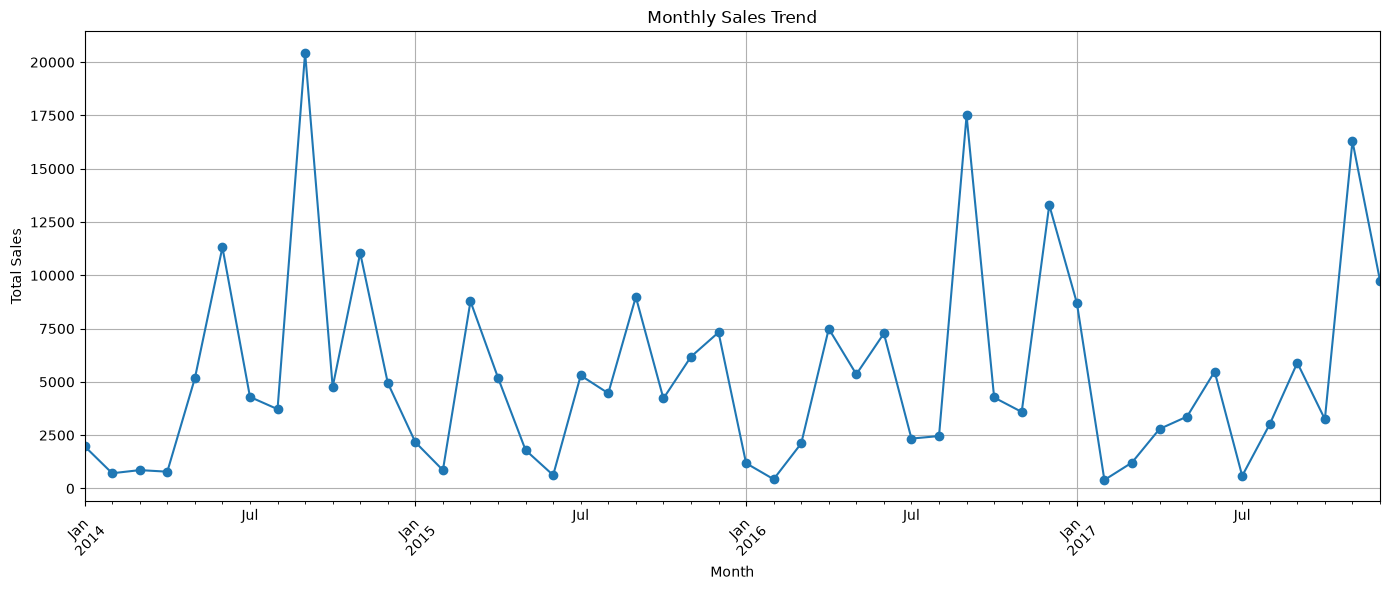

In [47]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line',marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights and Recommendations
#### 1. Seasonal Sales Patterns and Demand Fluctuations

The monthly sales trend indicates significant fluctuations in sales between 2014 and 2017. Sales generally appear to be weaker during the first few months of the year, while stronger sales activity is observed during the middle and later parts of the year. Several months recorded significant sales peaks, indicating possible seasonal demand patterns.

**Recommendation:**  
During historically low-sales periods, particularly at the beginning of the year, the company could introduce targeted promotional campaigns, limited-time discounts, and customer coupons to stimulate demand. During high-demand periods, inventory levels should be increased for popular products to ensure sufficient product availability and minimize potential lost sales due to stock shortages.



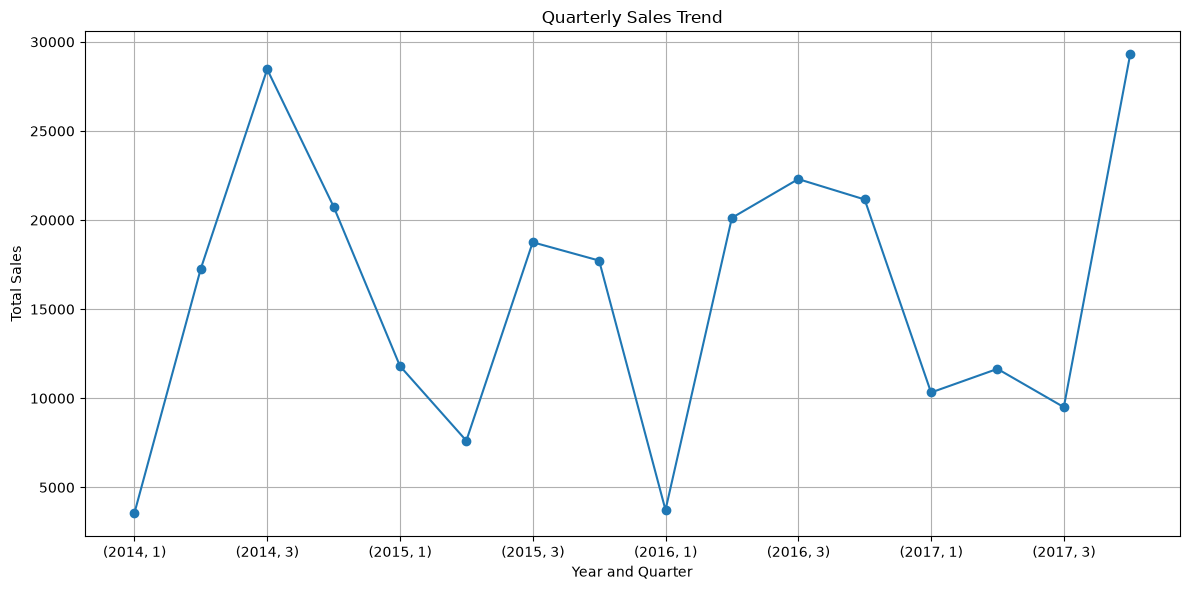

In [48]:
quarterly_sales = df.groupby([df['Order Date'].dt.year,df['Order Date'].dt.quarter])['Sales'].sum()

plt.figure(figsize=(12,6))
quarterly_sales.plot(kind='line',marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Year and Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Quarterly Sales Performance

The quarterly sales analysis further supports the presence of seasonal variation. Q4 of 2017 recorded the highest quarterly sales at approximately 29,000, while Q3 of 2014 was another strong-performing period at approximately 28,000. In contrast, Q1 of 2014 and Q1 of 2016 recorded considerably lower sales.

This suggests that sales performance tends to strengthen during certain later quarters, while the beginning of the year may experience weaker demand.

**Recommendation:**  
The company should use historical quarterly trends for demand forecasting and inventory planning. Marketing campaigns can be strengthened during weaker quarters, while inventory and operational capacity should be increased before historically high-performing quarters.


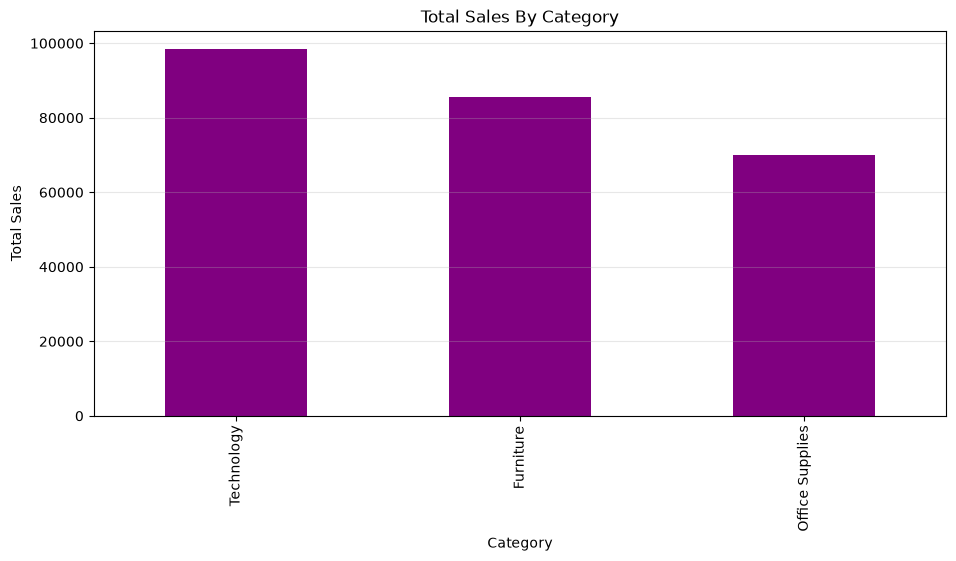

In [52]:
plt.figure(figsize=(11,5))
df.groupby('Category')["Sales"].sum().sort_values(ascending=False).plot(kind='bar',color='purple')
plt.title("Total Sales By Category")
plt.ylabel("Total Sales")
plt.grid(axis='y', alpha=0.3)
plt.show()

#### 3. Technology Leads in Total Sales

Technology is the highest-performing category by revenue, generating approximately 98,000 in total sales. Furniture follows with approximately 85,000, while Office Supplies generates approximately 70,000.

The strong performance of Technology indicates high customer demand for technology-related products and suggests that this category is an important revenue driver for the business.

**Recommendation:**  
The company should maintain sufficient inventory for high-demand Technology products and consider increasing targeted marketing efforts within this category. However, sales performance should always be evaluated alongside profitability to ensure that high revenue also contributes positively to overall business profit.


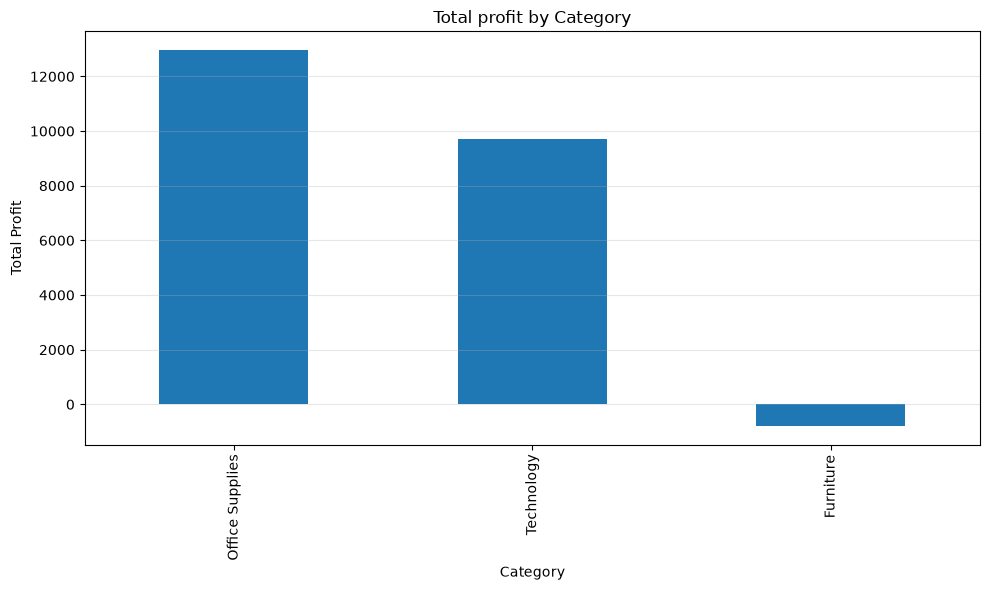

In [65]:
category_profit=(df.groupby('Category')['Profit'].sum().sort_values(ascending=False))

plt.figure(figsize=(10,6))
category_profit.plot(kind='bar')
plt.title('Total profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.show()

#### 4. High Sales Do Not Necessarily Translate into High Profitability

One of the most significant findings is the difference between category-level sales and profitability. Office Supplies generates the highest total profit at approximately 13,000 despite recording the lowest total sales among the three categories. Technology generates approximately 9,700 in profit.

In contrast, Furniture generates approximately 85,000 in sales but records an overall loss of approximately 800. This indicates that strong revenue performance does not necessarily translate into profitability.

**Recommendation:**  
The Furniture category should be investigated in greater detail at the sub-category and product levels. The company should identify products responsible for the largest losses and examine factors such as discount levels, pricing strategies, and product margins. Loss-making products may require revised pricing, reduced discounting, or other cost-control measures.


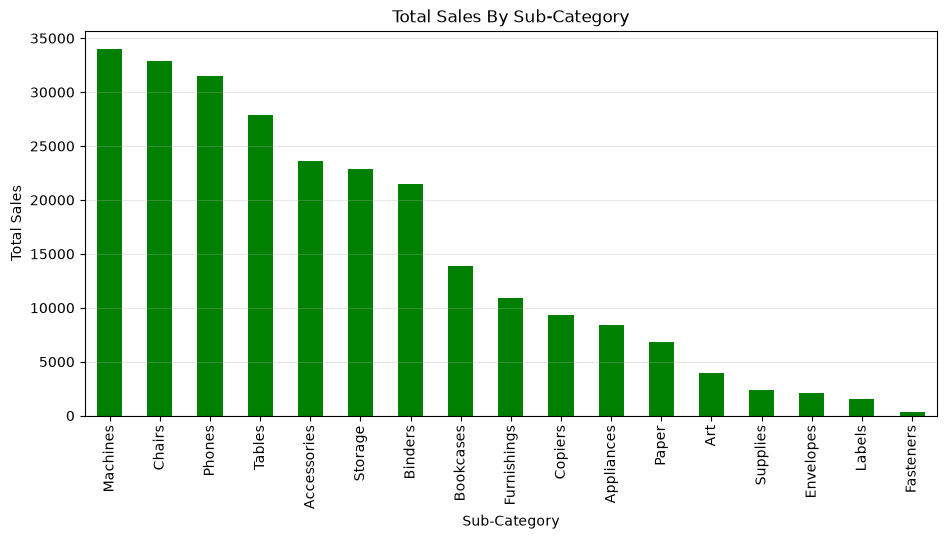

In [61]:
plt.figure(figsize=(11,5))
df.groupby('Sub-Category')["Sales"].sum().sort_values(ascending=False).plot(kind='bar',color='green')
plt.title("Total Sales By Sub-Category")
plt.ylabel("Total Sales")
plt.grid(axis='y', alpha=0.3)
plt.show()

#### 5. Machines, Chairs, and Phones Drive Sub-Category Sales

At the sub-category level, Machines generate the highest sales at approximately 34,000, followed by Chairs at approximately 33,000 and Phones at approximately 31,000. In contrast, sub-categories such as Fasteners, Labels, Envelopes, and Supplies generate substantially lower sales.

This indicates that a relatively small number of sub-categories contribute a significant portion of overall sales.

**Recommendation:**  
The company should prioritize inventory availability and marketing for high-performing sub-categories such as Machines, Chairs, and Phones. Lower-performing sub-categories should be evaluated individually to determine whether their performance can be improved through targeted promotions, product bundling, or changes in inventory allocation.


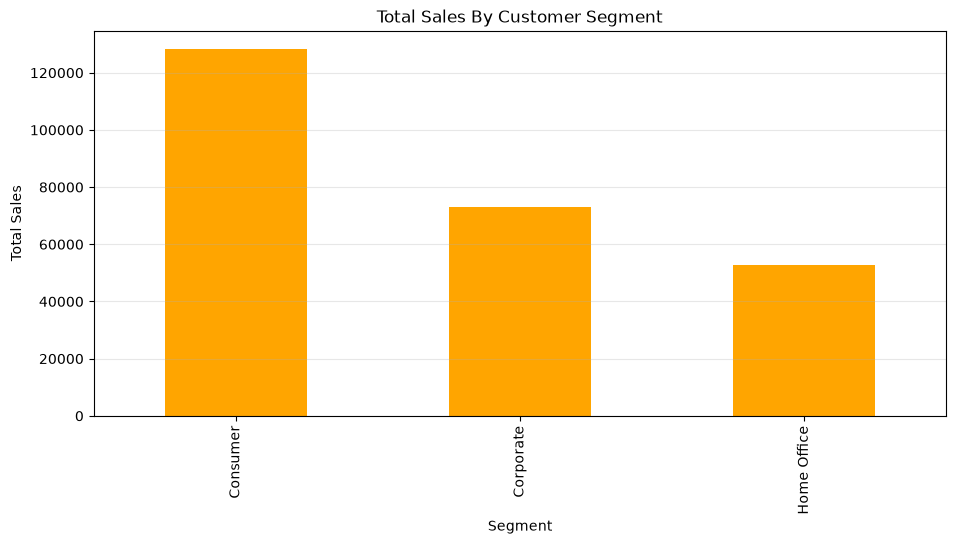

In [62]:
plt.figure(figsize=(11,5))
df.groupby('Segment')["Sales"].sum().sort_values(ascending=False).plot(kind='bar',color='Orange')
plt.title("Total Sales By Customer Segment")
plt.ylabel("Total Sales")
plt.grid(axis='y', alpha=0.3)
plt.show()


#### 6. Consumer Customers Represent the Largest Sales Segment

The Consumer segment is the largest contributor to total sales, generating approximately 128,000. This is considerably higher than the Corporate segment at approximately 73,000 and the Home Office segment at approximately 53,000.

This finding indicates that individual consumers represent the company's primary customer base and are an important driver of overall revenue.

**Recommendation:**  
The company should continue strengthening its relationship with Consumer customers through personalized promotions, loyalty programs, and targeted marketing campaigns. At the same time, the Corporate and Home Office segments represent potential areas for growth and could be targeted with specialized offers or bulk-purchase incentives.



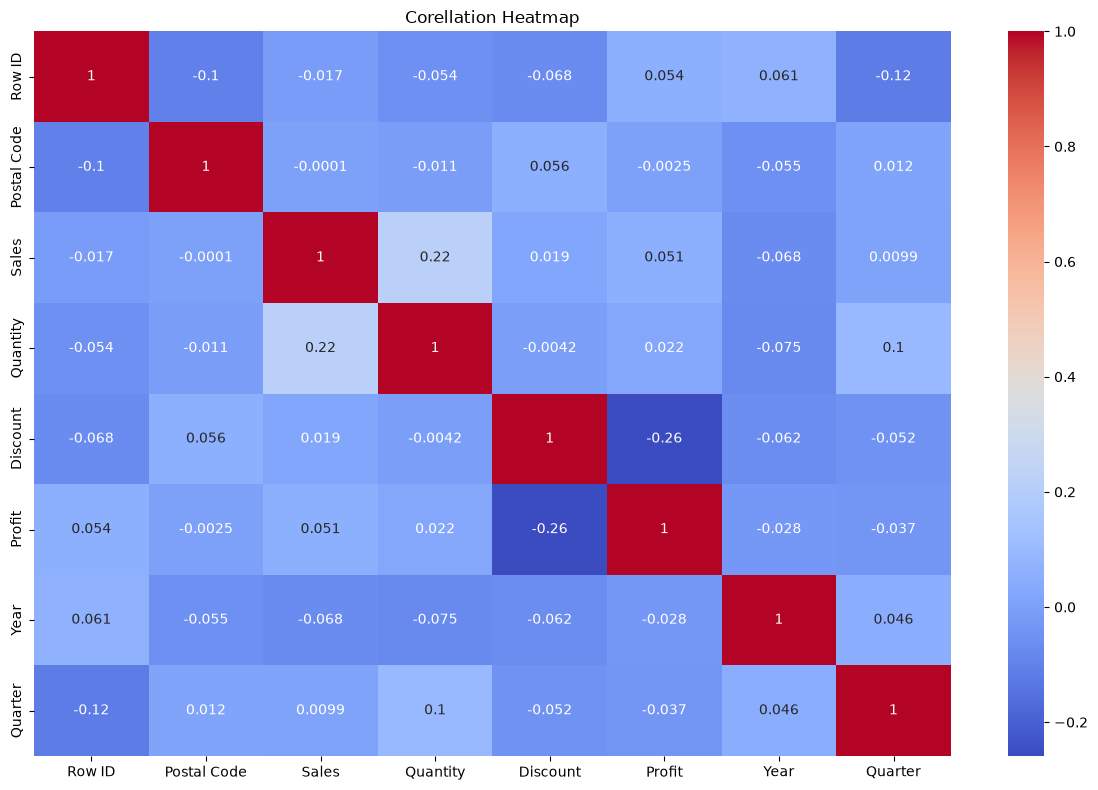

In [55]:
plt.figure(figsize=(12,8))
numeric_df= df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title("Corellation Heatmap")
plt.tight_layout()
plt.show()

#### 7. Higher Discounts Are Associated with Lower Profitability

The correlation analysis shows a negative correlation of approximately -0.26 between Discount and Profit. While this relationship is not extremely strong, it indicates that higher discount levels tend to be associated with lower profits.

This suggests that discounting may be one of the factors contributing to reduced profitability, particularly if high discounts are applied to products with already limited profit margins.

**Recommendation:**  
The company should review its discount strategy at the product and category levels. Discounts should be applied strategically rather than uniformly. Before offering large discounts, the company should evaluate the expected impact on profit margins. Promotional discounts may be more beneficial during low-demand periods, while unnecessary discounting during high-demand periods should be minimized.

#### 8. Quantity Has a Positive but Relatively Weak Relationship with Sales

The correlation between Sales and Quantity is approximately 0.22, indicating a positive but relatively weak relationship. Larger order quantities generally contribute to higher sales, but quantity alone does not strongly determine total sales value.

This suggests that factors such as product price, product category, and individual product value also play an important role in determining revenue.

**Recommendation:**  
The company could encourage larger purchases through carefully designed product bundles or volume-based promotions. However, these strategies should be monitored to ensure that discounts offered for larger quantities do not negatively affect overall profitability.



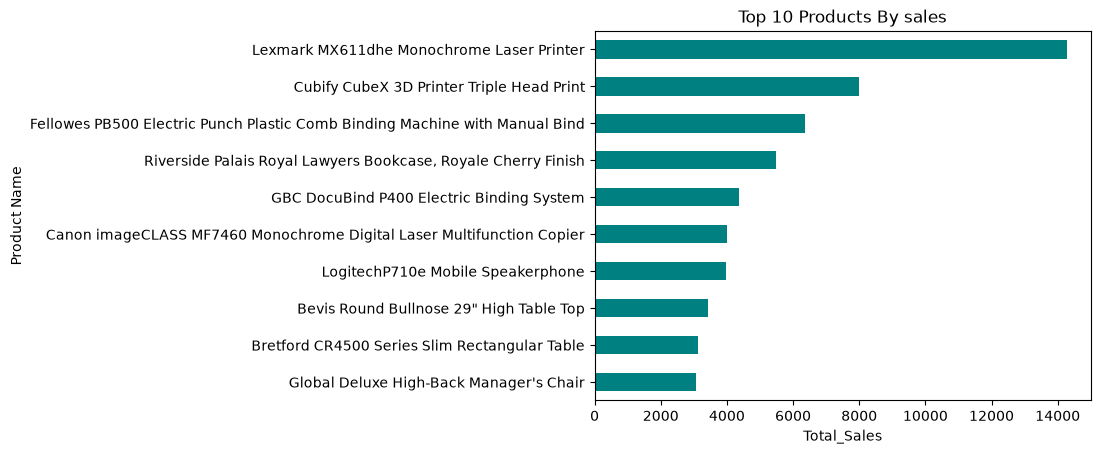

In [64]:
top_product= df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.Figure(figsize=(10,6))
top_product.plot(kind='barh',color='teal')
plt.title("Top 10 Products By sales")
plt.xlabel('Total_Sales')
plt.gca().invert_yaxis()
plt.show()



#### 9. High-Value Products Have a Significant Impact on Sales

The product-level analysis shows that the Lexmark MX611dhe Monochrome Laser Printer is the highest-selling individual product, generating approximately 14,000 in sales. The Cubify CubeX 3D Printer follows with approximately 8,000.

The substantial difference between the highest-selling product and other products suggests that certain high-value items can have a significant influence on overall sales performance.

**Recommendation:**  
The company should closely monitor demand and inventory levels for its highest-selling products to minimize the risk of stock shortages. However, these products should also be evaluated based on profit contribution rather than sales alone. A high-selling product should only be considered a strong performer if it also generates sustainable profit.



#### Overall Business Recommendations

Based on the exploratory data analysis, the following actions are recommended:

1. **Optimize seasonal inventory planning:** Increase inventory levels before historically high-demand periods and use targeted promotions, coupons, and marketing campaigns to stimulate demand during slower periods.

2. **Investigate Furniture profitability:** Conduct a deeper product and sub-category analysis to identify the specific Furniture products contributing to losses and review their pricing, margins, and discount levels.

3. **Optimize the discount strategy:** Reduce excessive discounting, particularly for low-margin products, and use discounts strategically during periods when additional demand needs to be generated.

4. **Prioritize profitable growth:** Continue supporting high-sales categories such as Technology while giving particular attention to Office Supplies, which demonstrates strong profitability despite lower overall sales.

5. **Strengthen customer segmentation strategies:** Maintain strong engagement with the Consumer segment while developing targeted strategies to increase revenue from Corporate and Home Office customers.

6. **Focus on high-performing products:** Ensure sufficient availability of top-selling products while continuously monitoring their profitability to ensure that high sales translate into meaningful business value.


#### Conclusion

The exploratory data analysis reveals clear differences in sales performance across time periods, product categories, sub-categories, customer segments, and individual products. Technology is the strongest category in terms of total sales, while Office Supplies generates the highest overall profit. The Consumer segment represents the largest source of revenue, and several high-value products make substantial contributions to total sales.

The most important business finding is that revenue alone is not a sufficient measure of performance. The Furniture category generates relatively strong sales but operates at an overall loss, demonstrating the importance of evaluating profitability alongside revenue. Furthermore, the negative relationship between Discount and Profit indicates that the company's discount strategy may require further optimization.

Overall, the analysis suggests that the company can improve business performance by adopting data-driven inventory planning, using targeted promotions during low-demand periods, optimizing discount strategies, addressing loss-making product areas, and prioritizing products and customer segments that contribute to sustainable profitability.
